In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('R:/PROJECTS/User Journey Funnel Analysis/user_journey_funnel_analysis/retail_user_behavior_100k.csv')

In [5]:
df.shape #Checking the dimesion of the dataset

(108584, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108584 entries, 0 to 108583
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   session_id         108584 non-null  str    
 1   user_id            108584 non-null  str    
 2   timestamp_utc      108584 non-null  str    
 3   event_index        108584 non-null  int64  
 4   user_action        108584 non-null  str    
 5   product_id         108584 non-null  str    
 6   category           108584 non-null  str    
 7   brand              108584 non-null  str    
 8   price              108584 non-null  float64
 9   channel            108584 non-null  str    
 10  device_type        108584 non-null  str    
 11  region             108584 non-null  str    
 12  traffic_source     108584 non-null  str    
 13  time_spent_sec     108584 non-null  int64  
 14  session_length     108584 non-null  int64  
 15  interaction_count  108584 non-null  int64  
 16  is_conversion

In [7]:
df.isna().sum() #Cheking the Null values

session_id           0
user_id              0
timestamp_utc        0
event_index          0
user_action          0
product_id           0
category             0
brand                0
price                0
channel              0
device_type          0
region               0
traffic_source       0
time_spent_sec       0
session_length       0
interaction_count    0
is_conversion        0
drop_off_flag        0
dtype: int64

In [8]:
df.duplicated().sum() #Checking the duplicates

np.int64(0)

In [9]:
df.describe()

,event_index,price,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
count,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000
mean,3.834626,249.497547,17.828317,6.669251,3.834626,0.038707,0.127063
std,2.238094,145.627749,9.356853,2.038962,2.238094,0.192897,0.333045
min,1.000000,7.290000,3.000000,3.000000,1.000000,0.000000,0.000000
25%,2.000000,119.950000,11.000000,5.000000,2.000000,0.000000,0.000000
50%,4.000000,253.850000,18.000000,7.000000,4.000000,0.000000,0.000000
75%,5.000000,376.080000,24.000000,8.000000,5.000000,0.000000,0.000000
max,13.000000,499.860000,64.000000,13.000000,13.000000,1.000000,1.000000


In [27]:
print(f'Number of Unique session is : {df['session_id'].nunique()}') #Number of unique sessions
print(f'Number of Unique user is : {df['user_id'].nunique()}') #Number of unique users


Number of Unique session is : 18000
Number of Unique user is : 6806


In [11]:
#Changing timestamp_utc to date type

df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
print(f'Data type of timestamp_utc column is : {df['timestamp_utc'].dtype}')

Data type of timestamp_utc column is : datetime64[us, UTC]


In [12]:
df['user_action'].value_counts()

user_action
view           44245
click          27735
drop           13797
add_to_cart    11642
wishlist        6962
purchase        4203
Name: count, dtype: int64

In [13]:
new_df = df[df['user_action'].isin(
    ['view', 'click', 'wishlist', 'add_to_cart', 'purchase']
)]

In [15]:
funnel = new_df.groupby('user_action')['user_id'].nunique().sort_values(ascending=False)
funnel

user_action
view           6806
click          6353
add_to_cart    5187
wishlist       4014
purchase       3238
Name: user_id, dtype: int64

C:\Users\rahul\AppData\Local\Temp\ipykernel_8312\3465559050.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = funnel_viz_df,x='user_action',y='user_counts',palette='viridis')


Text(0, 0.5, 'Number of Unique Users')

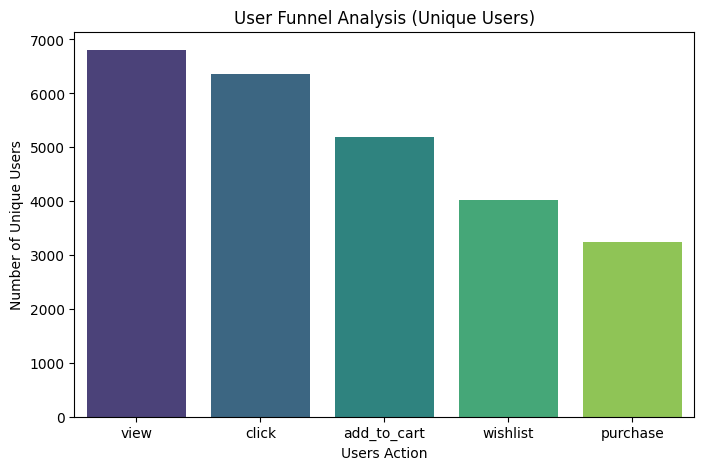

In [17]:
funnel_viz = {
    'user_action' : funnel.index,
    'user_counts' : funnel.values
}

funnel_viz_df = pd.DataFrame(funnel_viz)

plt.figure(figsize=(8,5))

sns.barplot(data = funnel_viz_df,x='user_action',y='user_counts',palette='viridis')

#Add titles and labels
plt.title('User Funnel Analysis (Unique Users)')
plt.xlabel('Users Action')
plt.ylabel('Number of Unique Users')


In [18]:
#Dividing the entire series by the value of the first step (view)
overall_conversion = (funnel / funnel.iloc[0]) * 100

print(overall_conversion.round(2))

user_action
view           100.00
click           93.34
add_to_cart     76.21
wishlist        58.98
purchase        47.58
Name: user_id, dtype: float64


In [19]:
#Shifting the series by 1 to align each step with its previous step
step_conversion = (funnel / funnel.shift(1)) * 100

#Fill the first step with 100% since it has no prior step
step_conversion = step_conversion.fillna(100)

print(step_conversion.round(2))

user_action
view           100.00
click           93.34
add_to_cart     81.65
wishlist        77.39
purchase        80.67
Name: user_id, dtype: float64


In [20]:
#Drop-off Analysis
drop_off = (funnel.shift(1)-funnel) 

#Fill the first step with 0 since as no one has drop-off
drop_off = drop_off.fillna(0)

print(drop_off.astype('int64'))

user_action
view              0
click           453
add_to_cart    1166
wishlist       1173
purchase        776
Name: user_id, dtype: int64


In [22]:
cumulative_dropoff = funnel.iloc[0] - funnel

print(cumulative_dropoff)

user_action
view              0
click           453
add_to_cart    1619
wishlist       2792
purchase       3568
Name: user_id, dtype: int64


In [24]:
#Drop-off rates
drop_off_rates = ((funnel.shift(1) - funnel) / funnel.shift(1)) * 100
drop_off_rates = drop_off_rates.fillna(100)
drop_off_rates.round(2)

user_action
view           100.00
click            6.66
add_to_cart     18.35
wishlist        22.61
purchase        19.33
Name: user_id, dtype: float64

In [29]:
# Define funnel stage order (business logic: how a real shopper journey progresses)
stage_order = ['view', 'click', 'wishlist', 'add_to_cart', 'purchase']

# For each session, find which stages it touched at least once
session_stages = new_df.groupby('session_id')['user_action'].apply(set)

funnel_counts = {}
for stage in stage_order:
    funnel_counts[stage] = session_stages.apply(lambda s: stage in s).sum()

total_sessions = df.session_id.nunique()
print('Total sessions:', total_sessions)
print()
print(f'{"Stage":<15}{"Sessions":<12}{"% of total":<12}')
for stage in stage_order:
    pct = funnel_counts[stage]/total_sessions*100
    print(f'{stage:<15}{funnel_counts[stage]:<12}{pct:.1f}%')

print()
print('Drop-off flagged sessions:', new_df[new_df.drop_off_flag==1].session_id.nunique())
print('Converted sessions (is_conversion=1):', new_df[new_df.is_conversion==1].session_id.nunique())


Total sessions: 18000

Stage          Sessions    % of total  
view           18000       100.0%
click          14116       78.4%
wishlist       5790        32.2%
add_to_cart    8833        49.1%
purchase       4203        23.4%

Drop-off flagged sessions: 0
Converted sessions (is_conversion=1): 4203
